# The Weekend Oracle — a quantitative teardown \U0001F52C
### Overlap accounting · closed-window panels · HC1 · a gold falsification control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The first
section is not about Bitcoin at all; it is about what time Yahoo closes a daily bar, which turns
out to determine whether the rest of the study means anything.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from weekendoracle import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
eq_px = px[data.EQUITY].dropna()
eq_rets = eq_px.pct_change()
cash_rets = rets[data.CASH].reindex(eq_px.index).fillna(0.0)
panel = st.attach_target(st.weekend_returns(px[data.CRYPTO].dropna(), eq_px.index), eq_rets)
print(f"as-of {data.AS_OF} | {len(panel):,} closed-market windows, "
      f"{panel.index[0].date()} -> {panel.index[-1].date()}")
print(panel.head().to_string())

as-of 2026-06-30 | 646 closed-market windows, 2014-09-22 -> 2026-06-29
           previous_session  gap_days  crypto_return  equity_return
session                                                            
2014-09-22       2014-09-19         3         0.0186        -0.0077
2014-09-29       2014-09-26         3        -0.0716        -0.0018
2014-10-06       2014-10-03         3        -0.0819        -0.0012
2014-10-13       2014-10-10         3         0.0798        -0.0164
2014-10-20       2014-10-17         3        -0.0024         0.0097


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Real | Over 646 closed-market windows (2014-09-22 → 2026-06-29), a 1% Bitcoin move across the weekend was followed by a **+4.019%** move in SPY on the next session (*t* = **+3.01**, R² 3.55%). The sign agreed 58.8% of the time against a 50% coin flip (*t* = +4.49), and the average next-session return was +0.242% after an up weekend against -0.187% after a down one (*t* = +4.64). Split at March 2020 the slope was +0.001 before and +0.086 after — the era in which Bitcoin became a high-beta Nasdaq position is doing most of the work. This is the **clean** design: zero hours of overlap, unlike the ordinary daily lead-lag correlation of -0.01, which shares 3 hours of clock with its own target. One thing this stamp must not be read as: Bitcoin's weekend move has a standard deviation of 5.3%, most of it Bitcoin's own business, so even a weekend whose news determined Monday perfectly could only produce a *t* of about **2.8** over 646 windows — a null here is weak evidence of absence, not strong evidence of nothing. |
| **Tradability** | Fragile | Buying SPY only on the session after an up crypto weekend — 363 of 646 windows, 56% of them — returned **+6.28%/yr** on those same sessions against **+2.64%** for holding every one of them regardless (+3.64%/yr, *t* = +1.72), after 2 bps a side. The rule is in the market about one session a week, so this is a comparison of like with like, not a Sharpe you can put next to a buy-and-hold Sharpe. |

> \U0001F4A1 **In plain words.** The clean experiment exists, it was run, and the R² is the
> number to read.

## 1 · Overlap accounting

Before any estimate, an audit of what each design's predictor window shares with its target's.

- Yahoo crypto daily bar: closes 00:00 UTC.
- NYSE: closes ~21:00 UTC.
- A closed-market window: Friday 21:00 UTC → Monday 14:30 UTC, with the target beginning after
  it ends.

In [3]:
rows = [{"design": a, "overlap_hours": st.overlap_hours(a), "clean": st.is_clean(a)}
        for a in ("same_day", "crypto_lead", "weekend")]
print(pd.DataFrame(rows).to_string(index=False))
grid = st.lead_lag_grid(rets[data.CRYPTO].dropna(), eq_rets.dropna())
print()
print(grid.round(4).to_string())

     design  overlap_hours  clean
   same_day        21.0000  False
crypto_lead         3.0000  False
    weekend         0.0000   True

                     description  correlation  overlap_hours  clean
lag                                                                
-5    equities lead crypto by 5d       0.0210        21.0000  False
-4    equities lead crypto by 4d      -0.0222        21.0000  False
-3    equities lead crypto by 3d      -0.0002        21.0000  False
-2    equities lead crypto by 2d       0.0213        21.0000  False
-1    equities lead crypto by 1d      -0.0575        21.0000  False
0                       same day       0.2353        21.0000  False
1    crypto leads equities by 1d      -0.0132         3.0000  False
2    crypto leads equities by 2d       0.0512         3.0000  False
3    crypto leads equities by 3d      -0.0035         3.0000  False
4    crypto leads equities by 4d       0.0132         3.0000  False
5    crypto leads equities by 5d       0.0082  

> \U0001F4A1 **In plain words.** Every row of the second table is contaminated. They are printed
> so that the reader can see what the usual version of this study would have concluded.

## 2 · The closed-window panel

                 previous_session  gap_days  crypto_return  equity_return
count                         646  646.0000       646.0000       646.0000
mean   2020-08-14 13:46:59.814000    3.0774         0.0068         0.0005
min           2014-09-19 00:00:00    2.0000        -0.2268        -0.1094
25%           2017-09-09 18:00:00    3.0000        -0.0192        -0.0035
50%           2020-08-03 12:00:00    3.0000         0.0038         0.0009
75%           2023-08-09 06:00:00    3.0000         0.0283         0.0058
max           2026-06-26 00:00:00    4.0000         0.2251         0.0672
std                           NaN    0.4094         0.0534         0.0114

gap_days
2     31
3    534
4     81


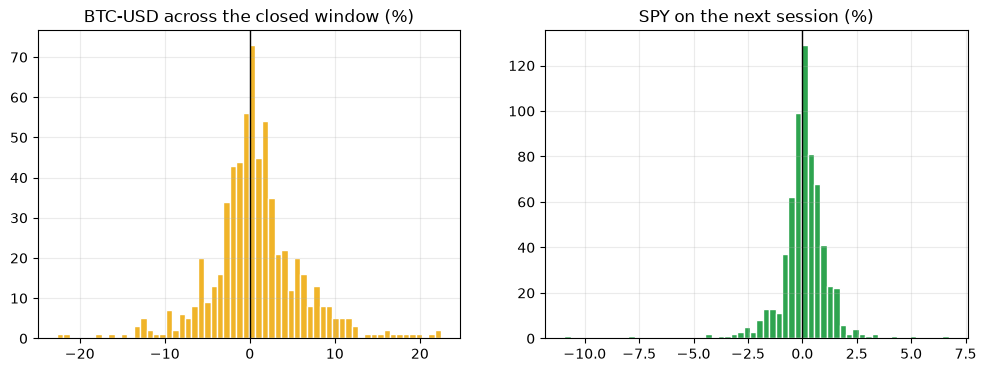

In [4]:
print(panel.describe().round(5).to_string())
print()
print(panel["gap_days"].value_counts().sort_index().to_string())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(panel["crypto_return"] * 100, bins=60, color="#f0b429", edgecolor="white")
axes[0].set_title(f"{data.CRYPTO} across the closed window (%)")
axes[1].hist(panel["equity_return"] * 100, bins=60, color="#2ea44f", edgecolor="white")
axes[1].set_title(f"{data.EQUITY} on the next session (%)")
for a in axes:
    a.axvline(0, color="k", lw=1)
plt.show()

## 3 · The teardown

### 3.1 The regression, with HC1 errors

In [5]:
reg = st.monday_regression(panel)
sa = st.sign_agreement(panel)
print(pd.Series({**{k: v for k, v in reg.items() if k != "alignment"},
                 "hit_rate": sa["hit_rate"],
                 "t_vs_coin_flip": sa["t_vs_coin_flip"]}).round(5).to_string())
print()
print(st.conditional_means(panel).round(5).to_string())

n                646.0000
alpha              0.0003
beta               0.0402
t                  3.0061
r2                 0.0355
overlap_hours      0.0000
hit_rate           0.5882
t_vs_coin_flip     4.4853

                       n    mean  median     sd      t
bucket                                                
crypto weekend up    363  0.0024  0.0019 0.0095    NaN
crypto weekend down  283 -0.0019 -0.0003 0.0131    NaN
difference           646  0.0043     NaN    NaN 4.6361


### 3.2 Regimes and closure lengths

                     n   beta      t     r2
regime                                     
before 2020-03-01  300 0.0015 0.0982 0.0001
since 2020-03-01   346 0.0856 3.9668 0.1078

          hours_closed    n    beta       t     r2
gap_days                                          
2              41.5000   31 -0.0195 -0.4070 0.0056
3              65.5000  534  0.0452  2.8706 0.0435
4              89.5000   81  0.0343  2.1306 0.0354


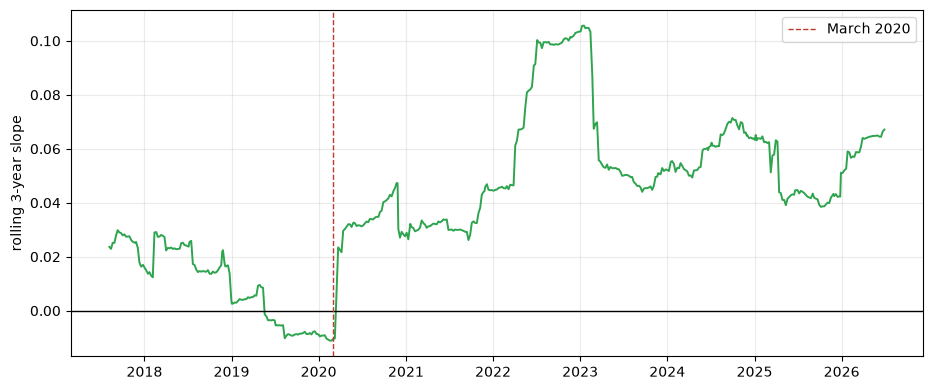

In [6]:
print(st.regime_split(panel).round(4).to_string())
print()
print(st.gap_length_buckets(panel).round(4).to_string())
roll = pd.Series(
    [st.monday_regression(panel.iloc[i - 156:i])["beta"] if i >= 156 else np.nan
     for i in range(len(panel))], index=panel.index)
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(roll.index, roll, lw=1.4, color="#2ea44f")
ax.axhline(0, color="k", lw=1)
ax.axvline(pd.Timestamp("2020-03-01"), color="#c0392b", ls="--", lw=1, label="March 2020")
ax.set_ylabel("rolling 3-year slope"); ax.legend()
plt.show()

### 3.3 The falsification control

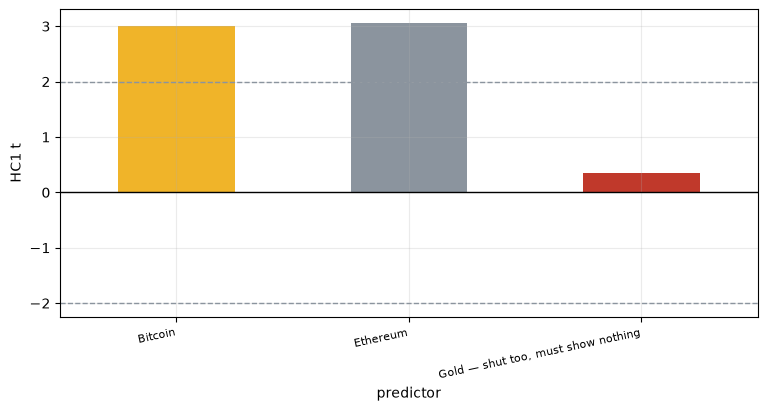

,n,beta,t,r2
predictor,,,,
Bitcoin,646,0.0402,3.0061,0.0355
Ethereum,476,0.0422,3.0553,0.0626
"Gold — shut too, must show nothing",1181,0.0207,0.3535,0.0003


In [7]:
rows = []
for label, tk in (("Bitcoin", data.CRYPTO), ("Ethereum", data.CRYPTO_2),
                  ("Gold — shut too, must show nothing", data.GOLD)):
    s = px[tk].dropna()
    if len(s) < 500:
        continue
    p = st.attach_target(st.weekend_returns(s, eq_px.index), eq_rets)
    r = st.monday_regression(p)
    rows.append({"predictor": label, "n": r["n"], "beta": r["beta"], "t": r["t"],
                 "r2": r["r2"]})
d = pd.DataFrame(rows).set_index("predictor")
fig, ax = plt.subplots(figsize=(9, 4))
d["t"].plot.bar(ax=ax, color=["#f0b429", "#8b949e", "#c0392b"])
ax.axhline(0, color="k", lw=1)
for y in (-2, 2):
    ax.axhline(y, ls="--", color="#8b949e", lw=1)
ax.set_ylabel("HC1 t")
plt.setp(ax.get_xticklabels(), rotation=12, ha="right", fontsize=8)
plt.show()
d.round(4)

### 3.4 The rule, and the only fair benchmark for it

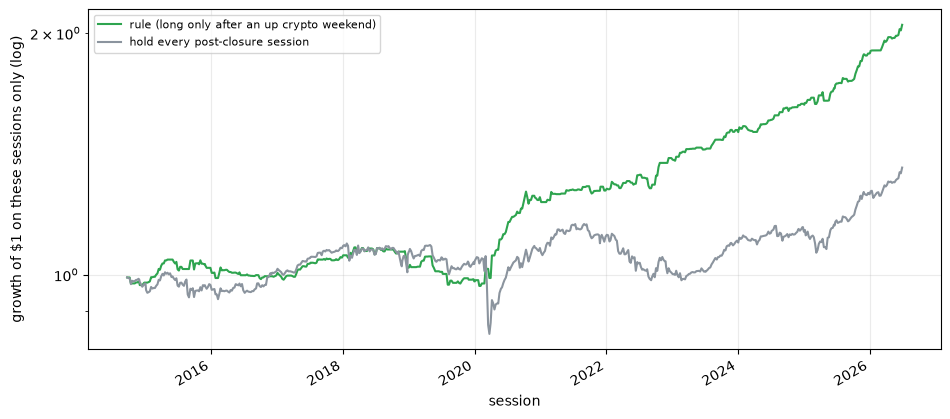

n_windows         646.0000
n_long            363.0000
share_long          0.5619
mean_rule           0.0011
mean_always         0.0005
total_rule          1.0476
total_always        0.3595
per_year_rule       0.0628
per_year_always     0.0264
t_gap               1.7229
cost_bps            2.0000


In [8]:
rule = st.monday_rule(panel, eq_rets, cash_rets, cost_bps=2.0)
curve = pd.DataFrame({
    "rule (long only after an up crypto weekend)": (1 + rule["returns"]).cumprod(),
    "hold every post-closure session": (1 + eq_rets.reindex(panel.index)).cumprod(),
})
fig, ax = plt.subplots(figsize=(11, 5))
curve.plot(ax=ax, logy=True, color=["#2ea44f", "#8b949e"])
ax.set_ylabel("growth of $1 on these sessions only (log)"); ax.legend(title="", fontsize=8)
plt.show()
print(pd.Series({k: v for k, v in rule.items() if k != "returns"}).round(5).to_string())

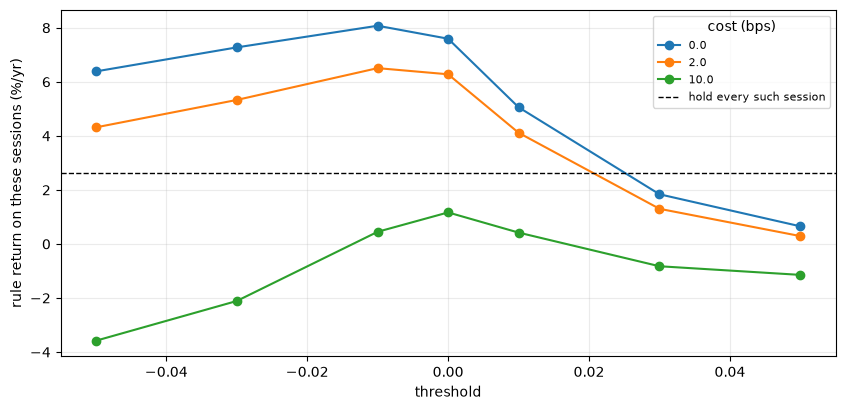

' threshold  cost_bps  share_long  per_year       t\n   -0.0500    0.0000      0.8963    0.0639  2.2503\n   -0.0500    2.0000      0.8963    0.0431  0.9569\n   -0.0500   10.0000      0.8963   -0.0358 -4.0885\n   -0.0300    0.0000      0.8344    0.0727  2.6673\n   -0.0300    2.0000      0.8344    0.0533  1.5113\n   -0.0300   10.0000      0.8344   -0.0211 -2.9902\n   -0.0100    0.0000      0.6672    0.0808  2.8599\n   -0.0100    2.0000      0.6672    0.0651  2.0089\n   -0.0100   10.0000      0.6672    0.0045 -1.3214\n    0.0000    0.0000      0.5619    0.0760  2.3813\n    0.0000    2.0000      0.5619    0.0628  1.7229\n    0.0000   10.0000      0.5619    0.0117 -0.8716\n    0.0100    0.0000      0.4118    0.0506  1.0516\n    0.0100    2.0000      0.4118    0.0412  0.5955\n    0.0100   10.0000      0.4118    0.0042 -1.2143\n    0.0300    0.0000      0.2415    0.0184 -0.4908\n    0.0300    2.0000      0.2415    0.0130 -0.7327\n    0.0300   10.0000      0.2415   -0.0083 -1.6955\n    0.0500 

In [9]:
rows = []
for thr in (-0.05, -0.03, -0.01, 0.0, 0.01, 0.03, 0.05):
    for c in (0.0, 2.0, 10.0):
        r = st.monday_rule(panel, eq_rets, cash_rets, cost_bps=c, threshold=thr)
        rows.append({"threshold": thr, "cost_bps": c, "share_long": r["share_long"],
                     "per_year": r["per_year_rule"], "t": r["t_gap"]})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 4.5))
d.pivot(index="threshold", columns="cost_bps", values="per_year").mul(100).plot(
    ax=ax, marker="o")
ax.axhline(rule["per_year_always"] * 100, color="k", ls="--", lw=1,
           label="hold every such session")
ax.set_ylabel("rule return on these sessions (%/yr)"); ax.legend(title="cost (bps)", fontsize=8)
plt.show()
d.round(4).to_string(index=False)

### 3.5 The ceiling: what this design could ever have seen

Before reading any null as evidence of absence. Bitcoin's weekend move is a *proxy* for the
weekend's news, and a noisy one; the correlation between proxy and news caps the correlation
between proxy and Monday, no matter how predictable Monday actually is.

max_correlation     0.1116
max_t               2.8357
n_weeks_for_t2    321.3471


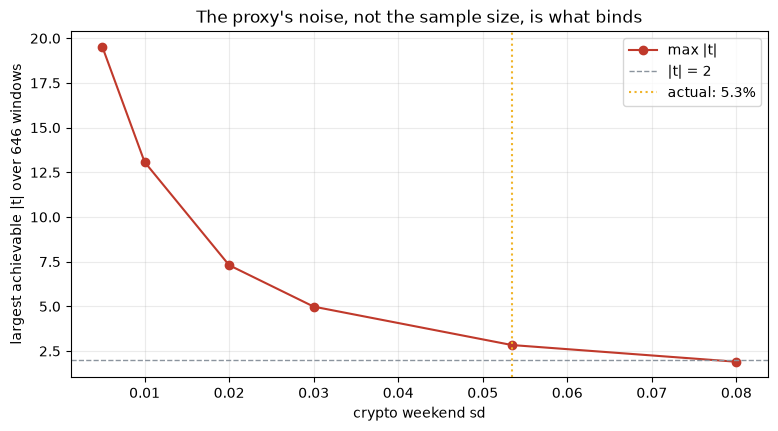

,max correlation,max |t|
crypto weekend sd,,
0.0050,0.7680,19.5260
0.0100,0.5140,13.0770
0.0200,0.2870,7.3030
0.0300,0.1960,4.9850
0.0534,0.1120,2.8360
0.0800,0.0750,1.9010


In [10]:
sd = panel["crypto_return"].std()
print(pd.Series(st.detectability_ceiling(len(panel), crypto_noise=sd)).round(4).to_string())
rows = []
for noise in (0.005, 0.01, 0.02, 0.03, sd, 0.08):
    c = st.detectability_ceiling(len(panel), crypto_noise=noise)
    rows.append({"crypto weekend sd": noise, "max correlation": c["max_correlation"],
                 "max |t|": c["max_t"]})
d = pd.DataFrame(rows).set_index("crypto weekend sd")
fig, ax = plt.subplots(figsize=(9, 4.5))
d["max |t|"].plot(ax=ax, marker="o", color="#c0392b")
ax.axhline(2, ls="--", color="#8b949e", lw=1, label="|t| = 2")
ax.axvline(sd, ls=":", color="#f0b429", lw=1.5, label=f"actual: {sd:.1%}")
ax.set_ylabel(f"largest achievable |t| over {len(panel)} windows"); ax.legend()
ax.set_title("The proxy's noise, not the sample size, is what binds")
plt.show()
d.round(3)

> \U0001F4A1 **In plain words.** If the vertical marker sits near or below the dashed line, this
> study could not have detected a real weekend effect even if one existed — and the honest
> report of that is a wide confidence interval, not a confident "no".

### 3.6 Power and size

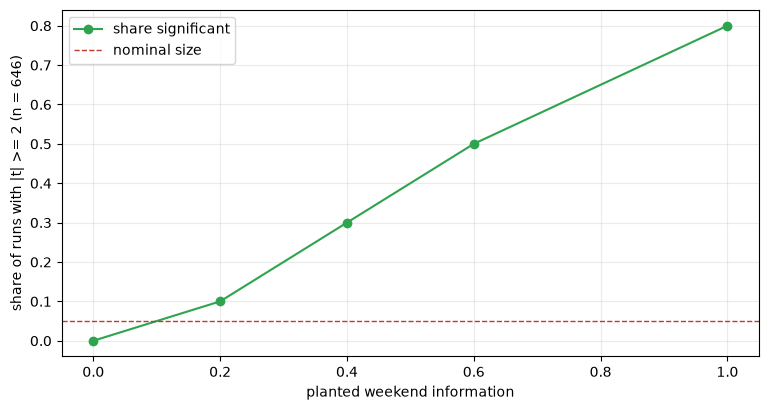

,mean |t|,share significant
planted weekend information,,
0.0000,0.9780,0.0000
0.2000,0.9230,0.1000
0.4000,1.3230,0.3000
0.6000,1.7480,0.5000
1.0000,2.3380,0.8000


In [11]:
rows = []
for info in (0.0, 0.2, 0.4, 0.6, 1.0):
    ts = [st.monday_regression(st.synthetic_world(n_weeks=len(panel),
                                                  weekend_information=info, seed=983 + s))["t"]
          for s in range(10)]
    rows.append({"planted weekend information": info, "mean |t|": np.nanmean(np.abs(ts)),
                 "share significant": np.mean(np.abs(ts) >= 2)})
d = pd.DataFrame(rows).set_index("planted weekend information")
fig, ax = plt.subplots(figsize=(9, 4.5))
d["share significant"].plot(ax=ax, marker="o", color="#2ea44f")
ax.axhline(0.05, ls="--", color="#c0392b", lw=1, label="nominal size")
ax.set_ylabel(f"share of runs with |t| >= 2 (n = {len(panel)})"); ax.legend()
plt.show()
d.round(3)

## 4 · The verdict

In [12]:
reg = st.monday_regression(panel)
rs = st.regime_split(panel)
rule = st.monday_rule(panel, eq_rets, cash_rets, cost_bps=2.0)
pd.DataFrame({
    "closed windows": [len(panel)],
    "slope": [reg["beta"]],
    "HC1 t": [reg["t"]],
    "R2": [reg["r2"]],
    "sign agreement": [st.sign_agreement(panel)["hit_rate"]],
    "slope before 2020-03": [rs.iloc[0]["beta"]],
    "slope since 2020-03": [rs.iloc[1]["beta"]],
    "largest |t| this design could give": [
        st.detectability_ceiling(len(panel), crypto_noise=panel["crypto_return"].std())["max_t"]],
    "rule vs same sessions (pp/yr)": [(rule["per_year_rule"] - rule["per_year_always"]) * 100],
    "t of that gap": [rule["t_gap"]],
}).T.rename(columns={0: "value"}).round(4)

,value
closed windows,646.0000
slope,0.0402
HC1 t,3.0061
R2,0.0355
sign agreement,0.5882
slope before 2020-03,0.0015
slope since 2020-03,0.0856
largest |t| this design could give,2.8357
rule vs same sessions (pp/yr),3.6353
t of that gap,1.7229


## 5 · Going further

- **Open-to-close targets.** If the weekend's information is priced at the opening auction, the
  close-to-close target used here measures the wrong thing. Reproducing this with intraday data
  is the single highest-value extension.
- **Event-conditioned weekends.** Restrict to closures containing a scheduled macro event.
- **The reverse direction.** Does Friday's equity session predict the weekend's crypto move?
  That design is also clean, and it is the one the data is most likely to say yes to.
- **Other 24/7 assets.** FX opens Sunday evening; the same experiment runs there with a
  seventeen-hour shorter window.